In [12]:
import sys
from pathlib import Path

# 🔑 Automatically locate project root by searching upward for the 'src' folder
project_root = Path.cwd()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent

# Insert at the front of sys.path so Python finds 'src' first
sys.path.insert(0, str(project_root))
print(f"✅ Project root resolved: {project_root}")

✅ Project root resolved: c:\Users\igor\Documents\GitHub\futures_trading_strategies


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src import (
    load_simple_price_csv,
    FixedRiskPositionStrategy,
    BuyAndHoldStrategy,
    VectorizedEngine,
    plot_results
)

In [14]:
data = load_simple_price_csv("../data/MCFTR.csv", date_format="%Y-%m-%d")
display(data.head())

2026-06-17 11:39:20.684 | INFO     | src.data.loader:load_simple_price_csv:47 - 📥 Loading simple price data: MCFTR.csv
2026-06-17 11:39:20.691 | INFO     | src.data.loader:load_simple_price_csv:81 - ✅ Loaded 5739 bars | Range: 2003-02-26 → 2026-02-13


,close
date,
2003-02-26,335.67
2003-02-27,338.35
2003-02-28,341.52
2003-03-03,352.24
2003-03-04,348.40


In [15]:
bh_strategy = BuyAndHoldStrategy(position_size=250)

In [16]:
engine = VectorizedEngine(
    initial_capital=100_000.0,     
    commission_rate=0.0004,
    slippage_rate=0.001
)

In [17]:
bh_result = engine.run(bh_strategy, data)

In [22]:
bh_result.print_summary()

┌──────────────────────────────────────────────────────────────────────
│ Strategy: BuyAndHoldStrategy                       │ Instrument               │
├──────────────────────────────────────────────────────────────────────┤
│ Years of data                            │                     22.8 │
│ Mean annual return                       │                   +13.8% │
│ Average drawdown                         │                    -4.2% │
│ Maximum drawdown                         │                   -71.3% │
│ Annualised standard deviation            │                    28.5% │
│ Sharpe ratio                             │                     0.48 │
│ Skew                                     │                    -0.65 │
│ Lower tail                               │                     2.16 │
│ Upper tail                               │                     1.59 │
└──────────────────────────────────────────────────────────────────────┘


🔬 Testing Buy & Hold position size sensitivity...
   1 contracts → Return:   7.13%, Sharpe: 0.35, Max DD: -4.0%
   2 contracts → Return:  14.27%, Sharpe: 0.35, Max DD: -7.5%
   5 contracts → Return:  35.67%, Sharpe: 0.37, Max DD: -15.7%
  10 contracts → Return:  71.34%, Sharpe: 0.38, Max DD: -24.4%
  20 contracts → Return: 142.68%, Sharpe: 0.41, Max DD: -34.0%
  40 contracts → Return: 285.36%, Sharpe: 0.44, Max DD: -42.3%
  60 contracts → Return: 428.04%, Sharpe: 0.45, Max DD: -46.0%
  80 contracts → Return: 570.72%, Sharpe: 0.46, Max DD: -50.8%
  100 contracts → Return: 713.40%, Sharpe: 0.46, Max DD: -55.5%
  150 contracts → Return: 1070.10%, Sharpe: 0.47, Max DD: -63.3%
  200 contracts → Return: 1426.80%, Sharpe: 0.48, Max DD: -68.1%
  250 contracts → Return: 1783.50%, Sharpe: 0.48, Max DD: -71.3%


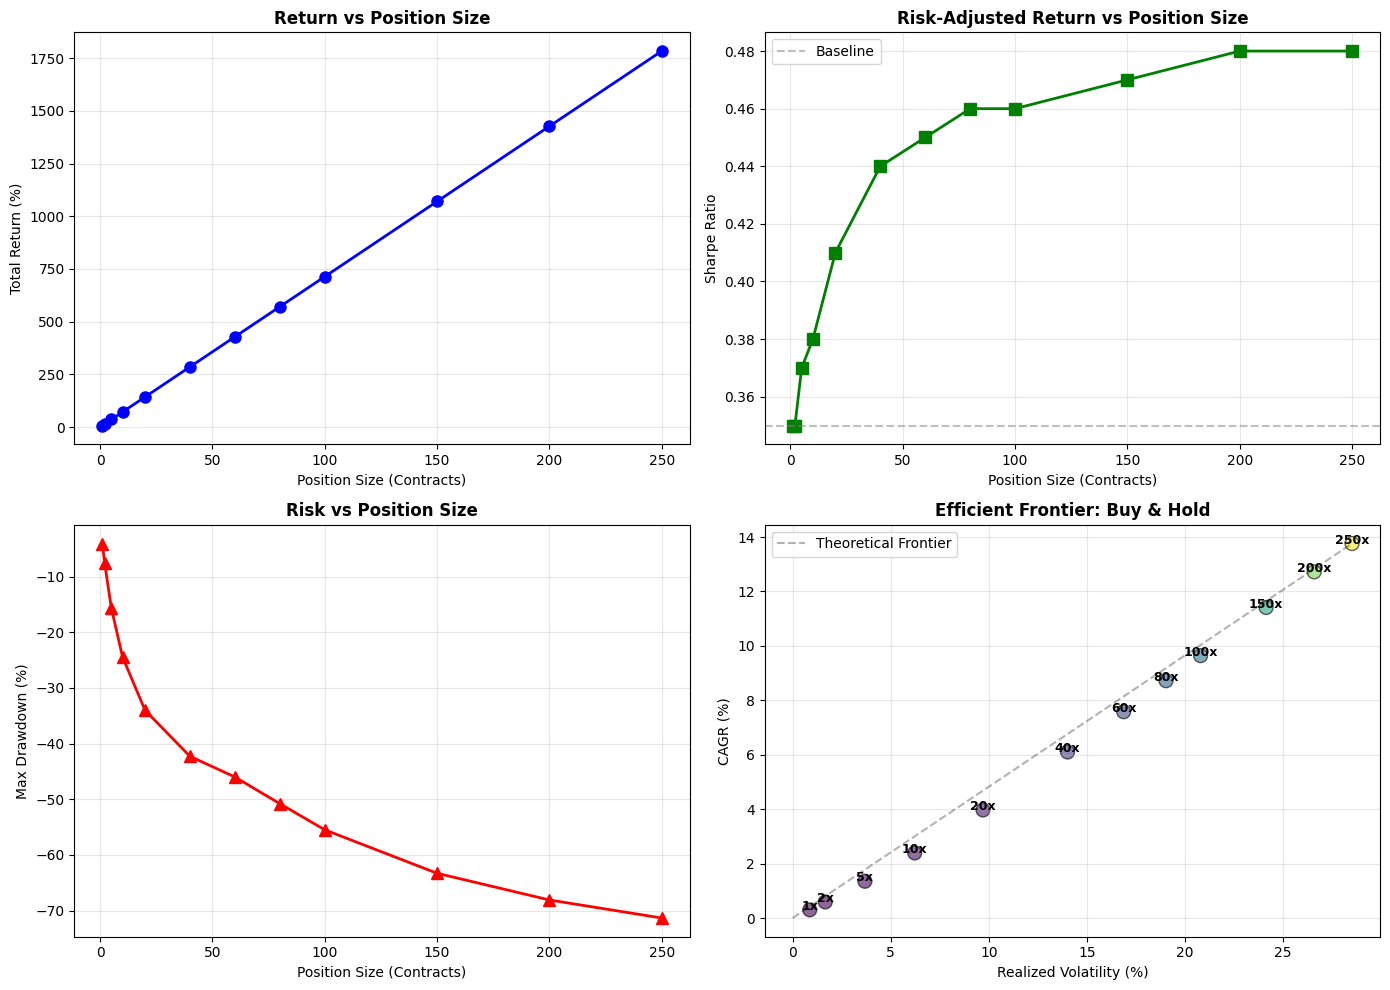

,Position Size (contracts),Total Return (%),CAGR (%),Sharpe Ratio,Max Drawdown (%),Volatility (%),Final Equity ($)
0,1,7.13,0.30,0.35,-4.04,0.87,107134.01
1,2,14.27,0.59,0.35,-7.53,1.66,114268.02
2,5,35.67,1.35,0.37,-15.65,3.68,135670.06
3,10,71.34,2.39,0.38,-24.45,6.22,171340.12
4,20,142.68,3.97,0.41,-34.01,9.70,242680.25
5,40,285.36,6.10,0.44,-42.28,14.01,385360.50
6,60,428.04,7.58,0.45,-46.00,16.87,528040.75
7,80,570.72,8.72,0.46,-50.79,19.03,670721.00
8,100,713.40,9.64,0.46,-55.49,20.79,813401.25
9,150,1070.10,11.41,0.47,-63.30,24.13,1170101.87


📊 Leverage Efficiency Analysis:
------------------------------------------------------------
Contracts  Return/Contract    Risk/Contract      Sharpe Stability
------------------------------------------------------------
1                       7.13%             -4.04%              1.00x
2                       7.13%             -3.77%              1.00x
5                       7.13%             -3.13%              1.06x
10                      7.13%             -2.44%              1.09x
20                      7.13%             -1.70%              1.17x
40                      7.13%             -1.06%              1.26x
60                      7.13%             -0.77%              1.29x
80                      7.13%             -0.63%              1.31x
100                     7.13%             -0.55%              1.31x
150                     7.13%             -0.42%              1.34x
200                     7.13%             -0.34%              1.37x
250                     7.13%   

In [19]:
# %% [markdown]
# ## Buy & Hold: Position Size Sensitivity Analysis
# 
# Test how different position sizes (number of contracts) affect performance.
# This isolates the impact of leverage on returns, risk, and risk-adjusted metrics.

# %%
# Configuration
INITIAL_CAPITAL = 100_000
POSITION_SIZES = [1, 2, 5, 10, 20, 40, 60, 80, 100, 150, 200, 250]  # Number of contracts to test
MULTIPLIER = 1.0  # For stocks/spot assets (point value)

# Engine setup
engine = VectorizedEngine(
    initial_capital=INITIAL_CAPITAL,
    point_value=MULTIPLIER,
    commission_rate=0.001,  # 0.1%
    slippage_rate=0.0005    # 0.05%
)

print("🔬 Testing Buy & Hold position size sensitivity...")
results_position = []

for n_contracts in POSITION_SIZES:
    # Create strategy with fixed position size
    strategy = BuyAndHoldStrategy(position_size=n_contracts)
    
    # Run backtest
    result = engine.run(
        strategy, 
        data, 
        strategy_name=f"Buy&Hold_{n_contracts}x", 
        ticker="SPX"
    )
    results_position.append(result)
    
    print(f"  {n_contracts:2d} contracts → Return: {result.metrics['total_return_pct']:6.2f}%, "
          f"Sharpe: {result.metrics['sharpe_ratio']:.2f}, "
          f"Max DD: {result.metrics['max_drawdown_pct']:.1f}%")

# %% [markdown]
# ### Position Size Sensitivity: Visual Analysis

# %%
# Extract metrics into DataFrame
position_metrics = pd.DataFrame({
    'Position Size (contracts)': POSITION_SIZES,
    'Total Return (%)': [r.metrics['total_return_pct'] for r in results_position],
    'CAGR (%)': [r.metrics['cagr_pct'] for r in results_position],
    'Sharpe Ratio': [r.metrics['sharpe_ratio'] for r in results_position],
    'Max Drawdown (%)': [r.metrics['max_drawdown_pct'] for r in results_position],
    'Volatility (%)': [r.metrics['annual_volatility_pct'] for r in results_position],
    'Final Equity ($)': [r.metrics['final_equity'] for r in results_position]
})

# Create 2x2 visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Total Return vs Position Size
axes[0, 0].plot(position_metrics['Position Size (contracts)'], 
                position_metrics['Total Return (%)'], 
                marker='o', linewidth=2, markersize=8, color='blue')
axes[0, 0].set_xlabel('Position Size (Contracts)')
axes[0, 0].set_ylabel('Total Return (%)')
axes[0, 0].set_title('Return vs Position Size', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: Sharpe Ratio vs Position Size (should be flat for Buy & Hold)
axes[0, 1].plot(position_metrics['Position Size (contracts)'], 
                position_metrics['Sharpe Ratio'], 
                marker='s', linewidth=2, markersize=8, color='green')
axes[0, 1].axhline(position_metrics['Sharpe Ratio'].iloc[0], 
                   color='gray', linestyle='--', alpha=0.5, label='Baseline')
axes[0, 1].set_xlabel('Position Size (Contracts)')
axes[0, 1].set_ylabel('Sharpe Ratio')
axes[0, 1].set_title('Risk-Adjusted Return vs Position Size', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Panel 3: Max Drawdown vs Position Size (linear relationship)
axes[1, 0].plot(position_metrics['Position Size (contracts)'], 
                position_metrics['Max Drawdown (%)'], 
                marker='^', linewidth=2, markersize=8, color='red')
axes[1, 0].set_xlabel('Position Size (Contracts)')
axes[1, 0].set_ylabel('Max Drawdown (%)')
axes[1, 0].set_title('Risk vs Position Size', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Panel 4: Efficient Frontier (Volatility vs CAGR)
# For Buy & Hold, this should be a straight line through origin
axes[1, 1].scatter(position_metrics['Volatility (%)'], 
                   position_metrics['CAGR (%)'], 
                   s=100, c=position_metrics['Position Size (contracts)'], 
                   cmap='viridis', alpha=0.6, edgecolors='black')

# Add position size labels
for _, row in position_metrics.iterrows():
    axes[1, 1].annotate(f"{int(row['Position Size (contracts)'])}x", 
                       (row['Volatility (%)'], row['CAGR (%)']),
                       fontsize=9, ha='center', fontweight='bold')

# Add reference line (theoretical efficient frontier for Buy & Hold)
if len(position_metrics) >= 2:
    slope = position_metrics['CAGR (%)'].iloc[-1] / position_metrics['Volatility (%)'].iloc[-1]
    x_line = np.linspace(0, position_metrics['Volatility (%)'].max(), 100)
    axes[1, 1].plot(x_line, slope * x_line, 'k--', alpha=0.3, label='Theoretical Frontier')

axes[1, 1].set_xlabel('Realized Volatility (%)')
axes[1, 1].set_ylabel('CAGR (%)')
axes[1, 1].set_title('Efficient Frontier: Buy & Hold', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/fixed_risk_strategy/08_buyhold_position_sensitivity.png", 
            dpi=150, bbox_inches='tight')
plt.show()

# Display metrics table
display(position_metrics.round(2))

# %% [markdown]
# ### Key Insights: Buy & Hold Position Sizing

# %%
# Calculate leverage efficiency metrics
position_metrics['Return per Contract'] = position_metrics['Total Return (%)'] / position_metrics['Position Size (contracts)']
position_metrics['Risk per Contract'] = position_metrics['Max Drawdown (%)'] / position_metrics['Position Size (contracts)']
position_metrics['Sharpe Stability'] = position_metrics['Sharpe Ratio'] / position_metrics['Sharpe Ratio'].iloc[0]

print("📊 Leverage Efficiency Analysis:")
print("-" * 60)
print(f"{'Contracts':<10} {'Return/Contract':<18} {'Risk/Contract':<18} {'Sharpe Stability'}")
print("-" * 60)
for _, row in position_metrics.iterrows():
    print(f"{int(row['Position Size (contracts)']):<10} "
          f"{row['Return per Contract']:17.2f}% "
          f"{row['Risk per Contract']:17.2f}% "
          f"{row['Sharpe Stability']:17.2f}x")

c:\Users\igor\Documents\GitHub\futures_trading_strategies\src\plots\mpl_plots.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


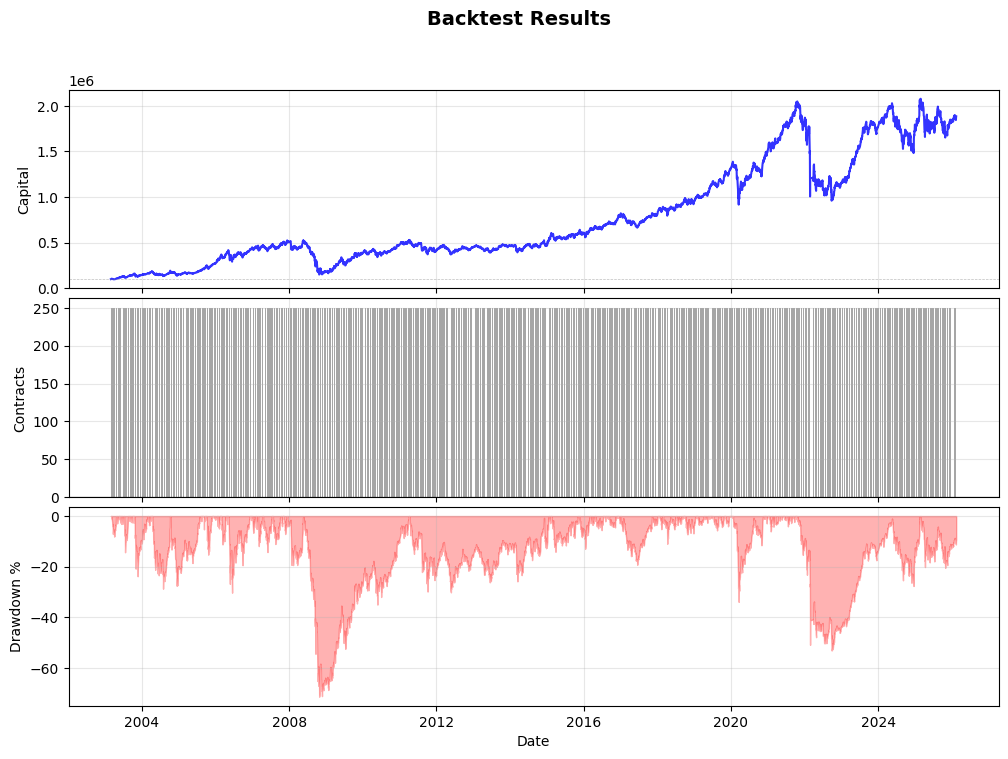

In [20]:
plot_results(bh_result)

In [21]:
import matplotlib.pyplot as plt